# Movie Recommendation System - EDA & Popularity Baseline
## Group 5 - AIL303m - Machine Learning | FPT University
**Syllabus Mapping:**
- 4 Retrieving and Cleaning Data
- 5, 6 Exploratory Data Analysis
- 18 Dimensionality Reduction & Matrix Factorization (Introduction)

**Objective:** EDA,  Popularity-based baseline recommendation system.

## 1. Configurations


In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from datetime import datetime

sns.set_style('darkgrid')
params = {
    'legend.fontsize': 'medium',
    'figure.figsize': (12, 8),
    'figure.dpi': 100,
    'axes.labelsize': 'medium',
    'axes.titlesize': 'large',
    'xtick.labelsize': 'medium',
    'ytick.labelsize': 'medium'
}
plt.rcParams.update(params)

print('Loaded!')

Loaded!


## 2. Data Loading
The MovieLens ml-latest-small dataset contains:
- **100,836 ratings** across **9,742 movies** by **610 users**
- Rating scale: 0.5 to 5.0 (half-star increments)
- Timeframe: March 1996 - September 2018

In [31]:
DATA_PATH = '../data/ml-latest-small/'

rating_df = pd.read_csv(DATA_PATH + 'ratings.csv')
movie_df = pd.read_csv(DATA_PATH + 'movies.csv')

print(f'Ratings shape: {rating_df.shape}')
print(f'Movies shape: {movie_df.shape}')

Ratings shape: (100836, 4)
Movies shape: (9742, 3)


In [32]:
# Preview ratings data
rating_df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [33]:
# Preview movies data
movie_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## 3. Dataset Overview

In [34]:

print('RATINGS DATASET INFO\n')

print(f'Total ratings: {len(rating_df):,}')
print(f'Unique users: {rating_df["userId"].nunique()}')
print(f'Unique movies: {rating_df["movieId"].nunique()}')
print(f'Rating range: {rating_df["rating"].min()} - {rating_df["rating"].max()}')
print(f'Average rating: {rating_df["rating"].mean():.2f}')
print()
print(f'Average ratings per user: {len(rating_df) / rating_df["userId"].nunique():.1f}')
print(f'Average ratings per movie: {len(rating_df) / rating_df["movieId"].nunique():.1f}')

# Sparsity analysis
n_users = rating_df['userId'].nunique()
n_movies = rating_df['movieId'].nunique()
n_ratings = len(rating_df)
sparsity = 1 - (n_ratings / (n_users * n_movies))
print()
print(f'Sparsity: {sparsity:.4f} ({sparsity*100:.1f}%)')
print(f'  {sparsity*100:.1f}% of the user-movie matrix is EMPTY')

RATINGS DATASET INFO

Total ratings: 100,836
Unique users: 610
Unique movies: 9724
Rating range: 0.5 - 5.0
Average rating: 3.50

Average ratings per user: 165.3
Average ratings per movie: 10.4

Sparsity: 0.9830 (98.3%)
  98.3% of the user-movie matrix is EMPTY


In [35]:
# Detailed statistics
rating_df.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


## 4. Exploratory Data Analysis (EDA)

### 4.1 Rating Distribution

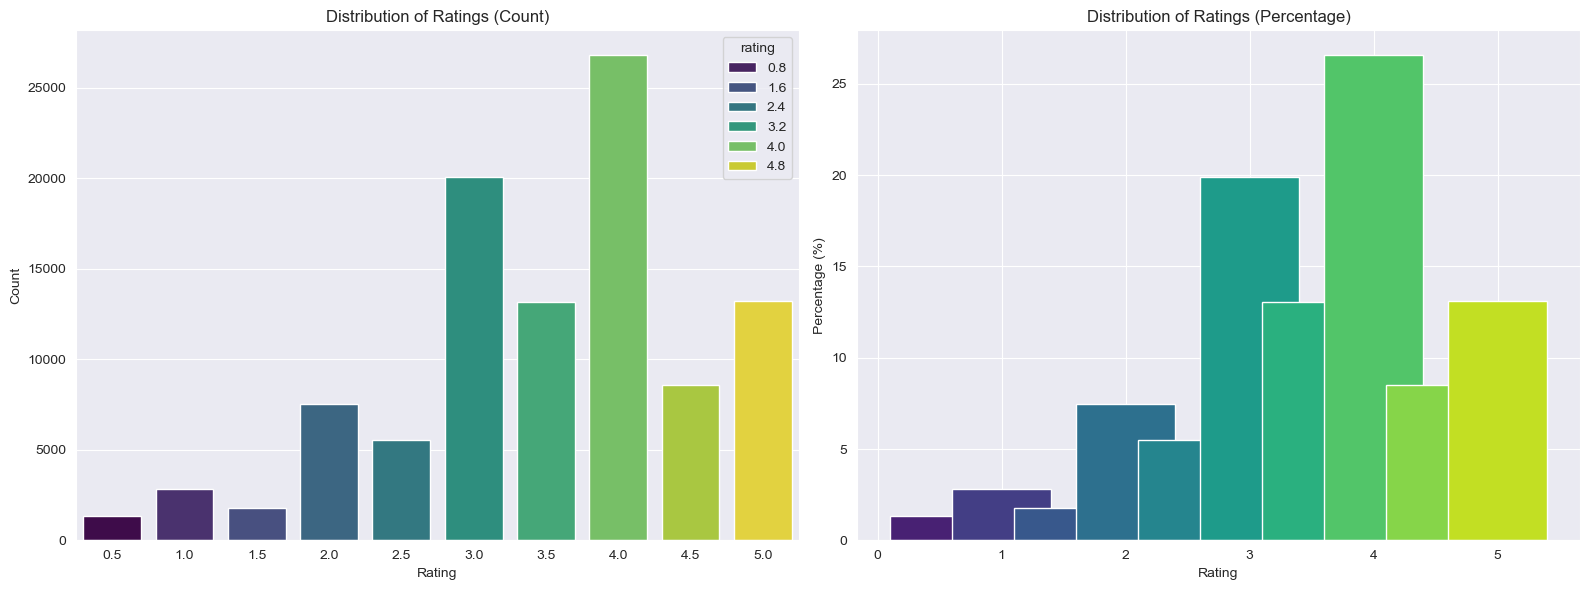

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count plot
sns.countplot(x='rating', data=rating_df, ax=axes[0], hue='rating', palette='viridis')
axes[0].set_title('Distribution of Ratings (Count)')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Percentage distribution
rating_counts = rating_df['rating'].value_counts(normalize=True).sort_index() * 100
axes[1].bar(rating_counts.index, rating_counts.values, color=sns.color_palette('viridis', len(rating_counts)))
axes[1].set_title('Distribution of Ratings (Percentage)')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Percentage (%)')

plt.tight_layout()
plt.show()

- **Key Insight:** Most ratings fall in the 3.0-4.0 range

- **Most common rating:** 4.0

- **Median rating:** 3.5

### 4.2 Top 20 Most Rated Movies (Popularity Bias)

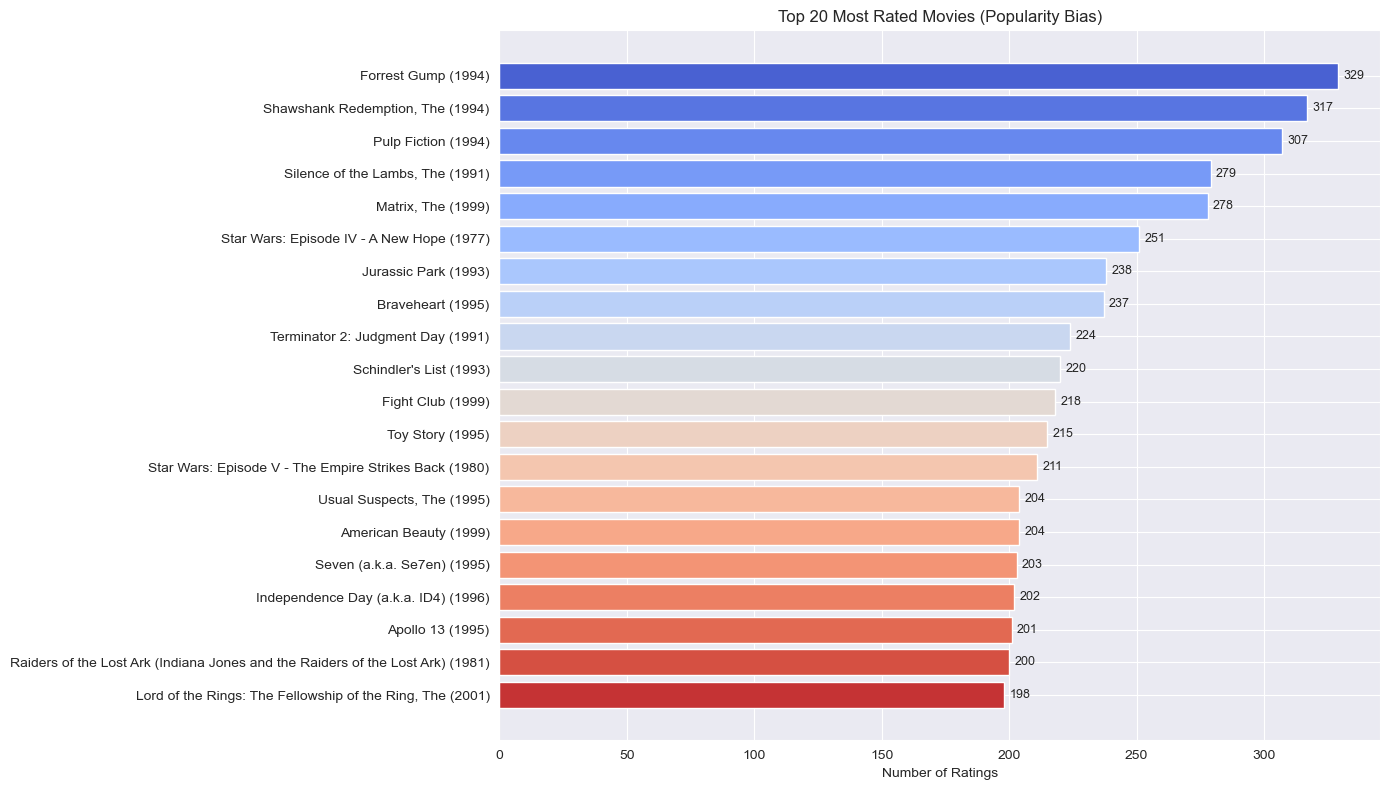

In [37]:
merged_df = pd.merge(rating_df, movie_df, on='movieId')

movie_rating_counts = merged_df.groupby('title').agg(
    count=('rating', 'count'),
    mean_rating=('rating', 'mean')
).reset_index().sort_values('count', ascending=False)

top20 = movie_rating_counts.head(20)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(range(len(top20)), top20['count'].values, color=sns.color_palette('coolwarm', len(top20)))
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['title'].values)
ax.invert_yaxis()
ax.set_xlabel('Number of Ratings')
ax.set_title('Top 20 Most Rated Movies (Popularity Bias)')

for i, v in enumerate(top20['count'].values):
    ax.text(v + 2, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

- **Key Insight:** Strong Popularity Bias

- **Top movie:** 329 ratings

- **Median movie:** 3 ratings

### 4.3 User Activity Distribution

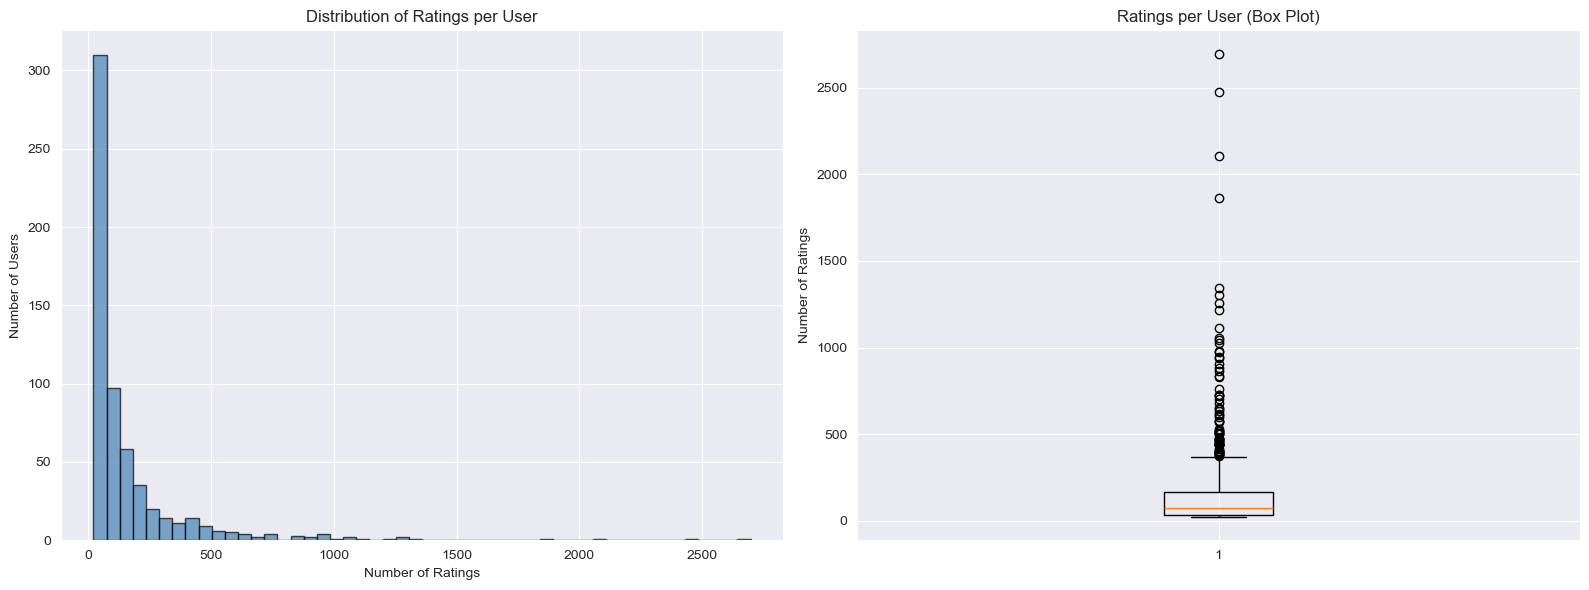

In [38]:
user_activity = rating_df.groupby('userId')['rating'].count().reset_index()
user_activity.columns = ['userId', 'num_ratings']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(user_activity['num_ratings'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Ratings per User')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Users')

axes[1].boxplot(user_activity['num_ratings'], vert=True)
axes[1].set_title('Ratings per User (Box Plot)')
axes[1].set_ylabel('Number of Ratings')

plt.tight_layout()
plt.show()

**User Activity Statistics:**
- Min ratings per user: 20
- Max ratings per user: 2698
- Mean ratings per user: 165.3
- Median ratings per user: 70

### 4.4 Genre Distribution

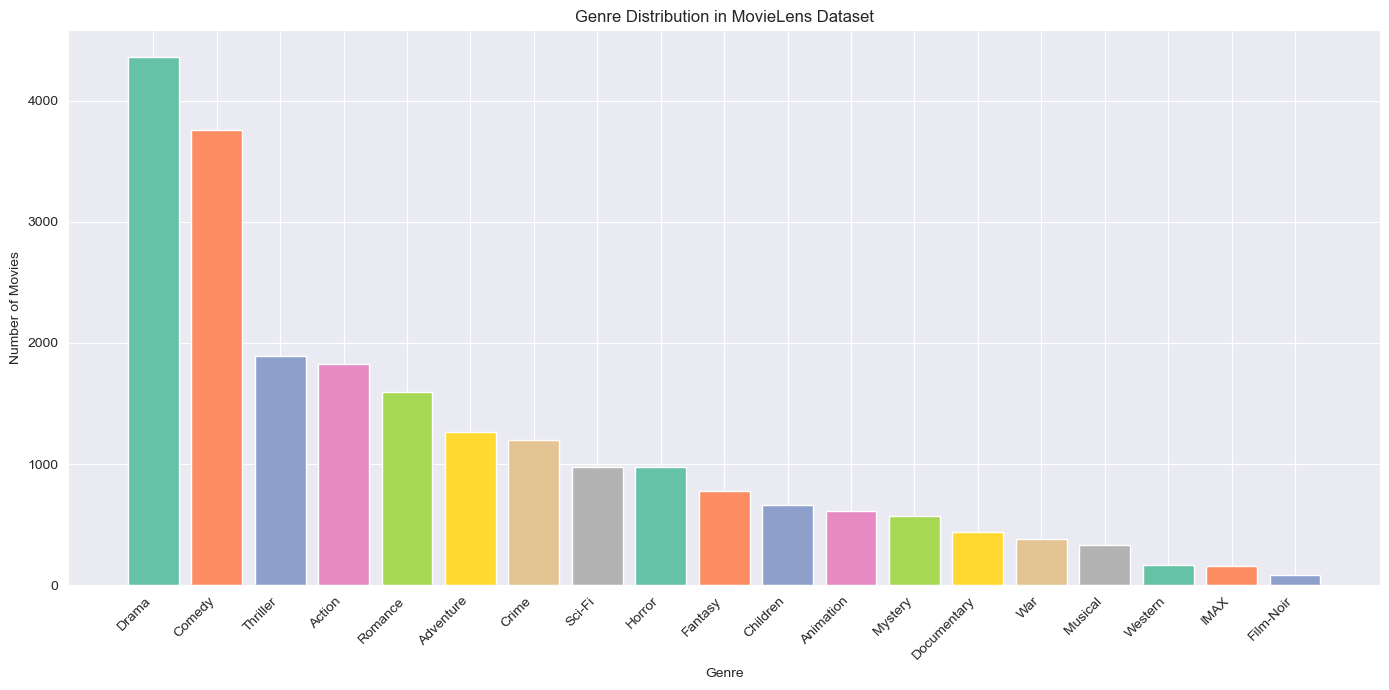

Top 5 Genres:
  Drama: 4361 movies
  Comedy: 3756 movies
  Thriller: 1894 movies
  Action: 1828 movies
  Romance: 1596 movies


In [39]:
all_genres = movie_df['genres'].str.split('|').explode()
genre_counts = all_genres.value_counts()
genre_counts = genre_counts[genre_counts.index != '(no genres listed)']

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.bar(range(len(genre_counts)), genre_counts.values, color=sns.color_palette('Set2', len(genre_counts)))
ax.set_xticks(range(len(genre_counts)))
ax.set_xticklabels(genre_counts.index, rotation=45, ha='right')
ax.set_xlabel('Genre')
ax.set_ylabel('Number of Movies')
ax.set_title('Genre Distribution in MovieLens Dataset')

plt.tight_layout()
plt.show()

print('Top 5 Genres:')
for genre, count in genre_counts.head(5).items():
    print(f'  {genre}: {count} movies')

### 4.5 Temporal Trends (Ratings Over Time)

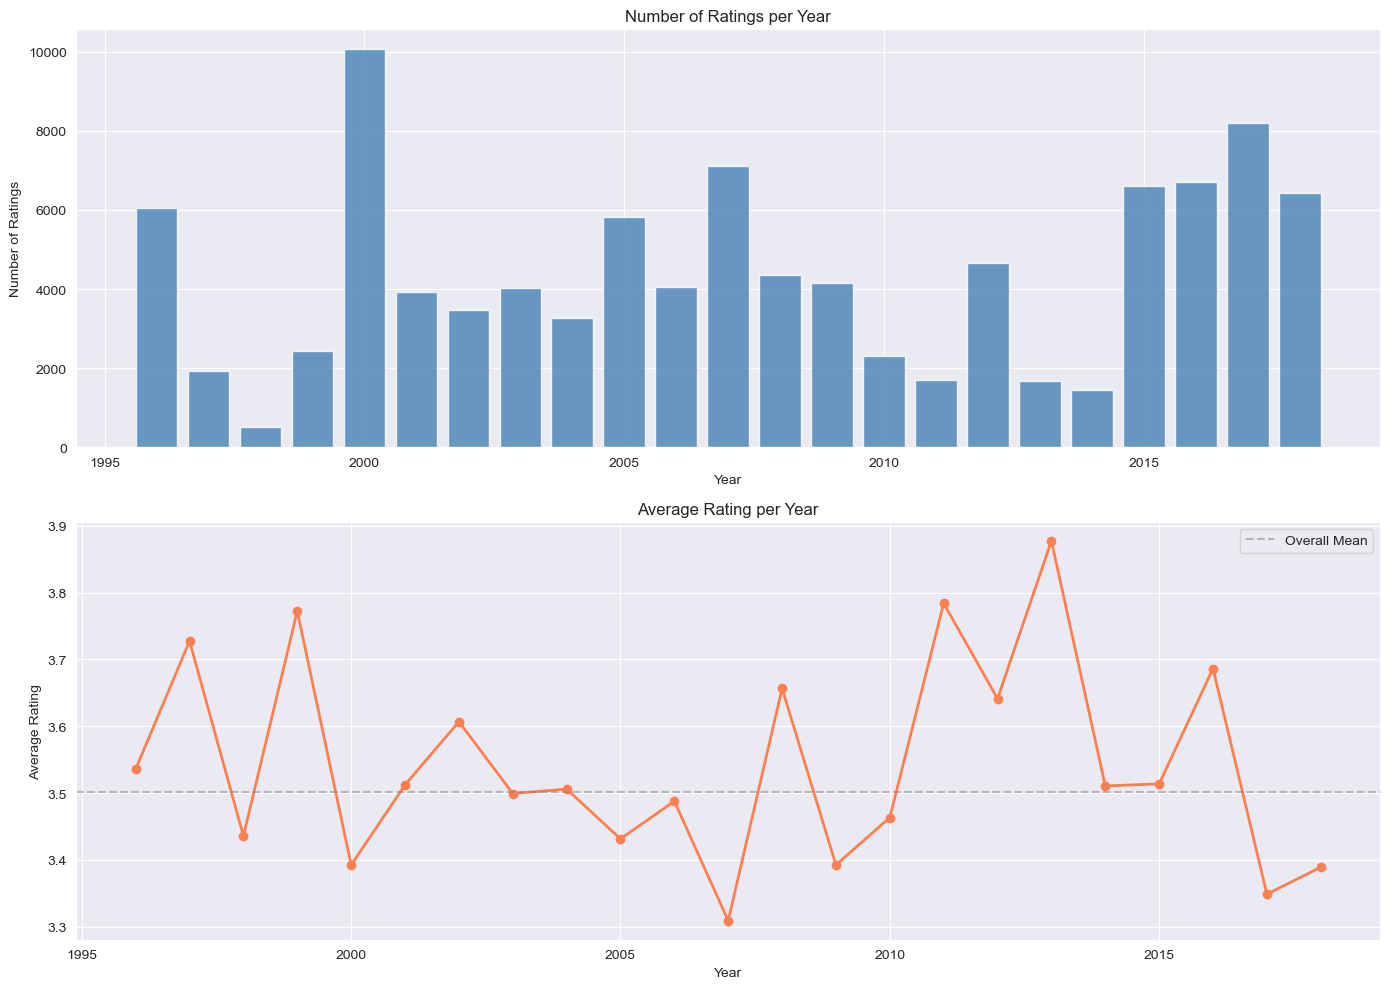

Temporal Range: 1996 - 2018


In [40]:
rating_df['datetime'] = pd.to_datetime(rating_df['timestamp'], unit='s')
rating_df['year'] = rating_df['datetime'].dt.year

yearly_ratings = rating_df.groupby('year').agg(
    count=('rating', 'count'),
    mean_rating=('rating', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].bar(yearly_ratings['year'], yearly_ratings['count'], color='steelblue', alpha=0.8)
axes[0].set_title('Number of Ratings per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Ratings')

axes[1].plot(yearly_ratings['year'], yearly_ratings['mean_rating'], 'o-', color='coral', linewidth=2)
axes[1].set_title('Average Rating per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Rating')
axes[1].axhline(y=rating_df['rating'].mean(), color='gray', linestyle='--', alpha=0.5, label='Overall Mean')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Temporal Range: {yearly_ratings["year"].min()} - {yearly_ratings["year"].max()}')

### 4.6 Sparsity Visualization

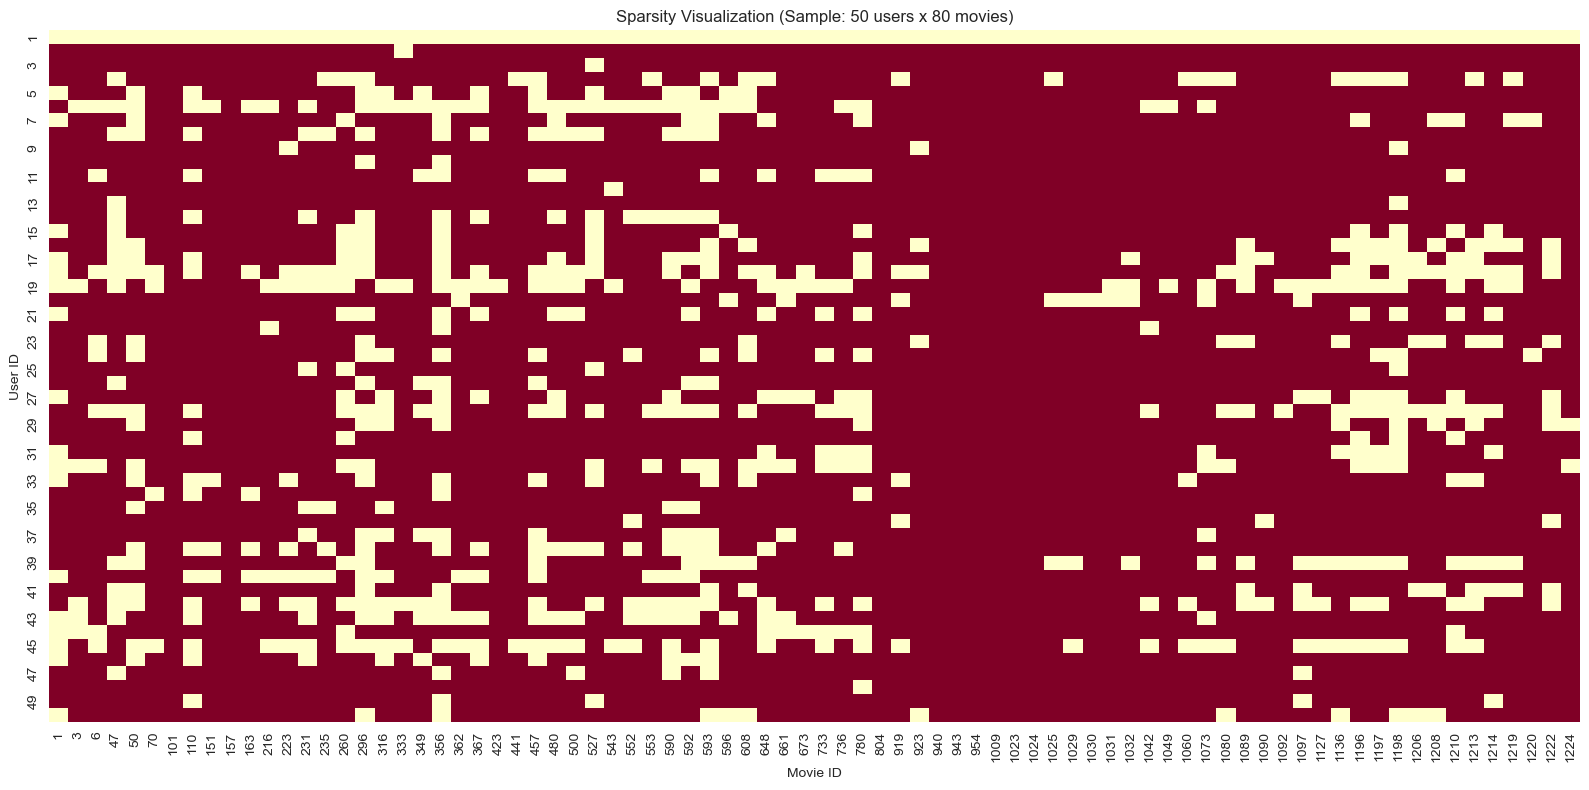

Matrix Sparsity: 98.3% of entries are missing
  Full matrix size: 610 x 9724 = 5,931,640 cells
  Known ratings: 100,836
  Missing entries: 5,830,804


In [41]:
# sample data
sample_users = rating_df['userId'].unique()[:50] # 50 users
sample_movies = rating_df[rating_df['userId'].isin(sample_users)]['movieId'].unique()[:80] # 80 movies

sample_df = rating_df[
    (rating_df['userId'].isin(sample_users)) &
    (rating_df['movieId'].isin(sample_movies))
]

user_movie_matrix = sample_df.pivot_table(
    index='userId', columns='movieId', values='rating'
)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(user_movie_matrix.isnull(), cbar=False, cmap='YlOrRd', ax=ax)
ax.set_title(f'Sparsity Visualization (Sample: {len(sample_users)} users x {len(sample_movies)} movies)')
ax.set_xlabel('Movie ID')
ax.set_ylabel('User ID')

plt.tight_layout()
plt.show()

print(f'Matrix Sparsity: {sparsity*100:.1f}% of entries are missing')
print(f'  Full matrix size: {n_users} x {n_movies} = {n_users * n_movies:,} cells')
print(f'  Known ratings: {n_ratings:,}')
print(f'  Missing entries: {n_users * n_movies - n_ratings:,}')

## 5. Popularity-Based Recommendation

### Popularity Baseline:

**Formula:** `weighted_score = (avg_rating * num_votes) / (num_votes + threshold)`

This approach recommends the most popular movies to ALL users (no personalization).
It serves as a **baseline** and **cold-start fallback**.

In [42]:
movie_stats = merged_df.groupby(['movieId', 'title']).agg(
    avg_rating=('rating', 'mean'),
    num_ratings=('rating', 'count')
).reset_index()

threshold = movie_stats['num_ratings'].quantile(0.9)
print(f'Threshold (90th percentile): {threshold:.0f} ratings')

movie_stats['weighted_score'] = (
    (movie_stats['avg_rating'] * movie_stats['num_ratings']) /
    (movie_stats['num_ratings'] + threshold)
)

top10_popular = movie_stats[movie_stats['num_ratings'] >= threshold].sort_values(
    'weighted_score', ascending=False
).head(10)

print('\nTop-10 Popularity-Based Recommendations (for new/cold-start users):')

print('=' * 95)

for i, (_, row) in enumerate(top10_popular.iterrows(), 1):
    print(f'  {i:2d}. {row["title"]:<50s} '
          f'Avg: {row["avg_rating"]:.2f}  '
          f'Count: {int(row["num_ratings"])}  '
          f'Score: {row["weighted_score"]:.3f}')

Threshold (90th percentile): 27 ratings

Top-10 Popularity-Based Recommendations (for new/cold-start users):
   1. Shawshank Redemption, The (1994)                   Avg: 4.43  Count: 317  Score: 4.081
   2. Pulp Fiction (1994)                                Avg: 4.20  Count: 307  Score: 3.858
   3. Forrest Gump (1994)                                Avg: 4.16  Count: 329  Score: 3.848
   4. Matrix, The (1999)                                 Avg: 4.19  Count: 278  Score: 3.821
   5. Star Wars: Episode IV - A New Hope (1977)          Avg: 4.23  Count: 251  Score: 3.820
   6. Fight Club (1999)                                  Avg: 4.27  Count: 218  Score: 3.802
   7. Silence of the Lambs, The (1991)                   Avg: 4.16  Count: 279  Score: 3.794
   8. Schindler's List (1993)                            Avg: 4.22  Count: 220  Score: 3.763
   9. Godfather, The (1972)                              Avg: 4.29  Count: 192  Score: 3.760
  10. Usual Suspects, The (1995)                      

In [43]:
from sklearn.metrics import mean_squared_error

global_mean = rating_df['rating'].mean()

baseline_rmse = np.sqrt(mean_squared_error(
    rating_df['rating'],
    np.full(len(rating_df), global_mean)
))

baseline_mae = np.mean(np.abs(rating_df['rating'] - global_mean))

print(f'Baseline (Global Mean) Performance:')
print(f'  Global Mean Rating: {global_mean:.4f}')
print(f'  Baseline RMSE: {baseline_rmse:.4f}')
print(f'  Baseline MAE: {baseline_mae:.4f}')

Baseline (Global Mean) Performance:
  Global Mean Rating: 3.5016
  Baseline RMSE: 1.0425
  Baseline MAE: 0.8271


## 6. Summary

### Key Findings:
1. **Sparsity**: 98.3% of the user-movie matrix is empty - requires Matrix Completion
2. **Popularity Bias**: Top movies have 200-300+ ratings, median movie has only ~3 ratings
3. **Rating Distribution**: Most ratings are 3.0-4.0 (positive skew)
4. **Temporal Range**: 22 years of data (1996-2018)
5. **Baseline RMSE**: ~1.13 (using global mean prediction)